In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
data_path = os.path.join('..', 'include', 'pipeline', 'data', 'raw', 'world_bank', 'data_world_bank.csv')
df_world_bank = pd.read_csv(data_path)

df_world_bank.head(100)

,Country,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate
0,Afghanistan,1980,NaN,9000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.258,13169311.0,15.680999
1,Afghanistan,1981,NaN,180000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.406,11937581.0,15.903758
2,Afghanistan,1982,NaN,100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.058,10991378.0,16.107378
3,Afghanistan,1983,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.517,10917982.0,16.293666
4,Afghanistan,1984,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.473,11190221.0,16.464427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Angola,1985,NaN,278000000.0,7.554065e+09,3.499999,772.468833,NaN,NaN,NaN,0.0,42.495,9779120.0,30.916115
96,Angola,1986,NaN,234000000.0,7.072536e+09,2.900002,697.526602,NaN,NaN,NaN,0.0,42.739,10139450.0,32.321814
97,Angola,1987,NaN,119000000.0,8.084412e+09,4.082749,770.101140,NaN,NaN,NaN,0.0,40.786,10497858.0,33.727677
98,Angola,1988,NaN,131000000.0,8.769837e+09,6.128890,807.439628,NaN,NaN,NaN,0.0,41.471,10861291.0,35.126880


In [3]:
countries = df_world_bank['Country'].unique()
print(countries)
len(countries)

['Afghanistan' 'Algeria' 'Angola' 'Argentina' 'Australia' 'Austria'
 'Bangladesh' 'Belarus' 'Belgium' 'Bolivia' 'Brazil' 'Bulgaria' 'Cambodia'
 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus'
 'Czech Republic' 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Estonia' 'Ethiopia' 'Finland' 'France' 'Germany' 'Ghana'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kuwait' 'Laos' 'Latvia' 'Lebanon' 'Lithuania' 'Luxembourg'
 'Malaysia' 'Malta' 'Mexico' 'Morocco' 'Myanmar' 'Nepal' 'Netherlands'
 'New Zealand' 'Nigeria' 'Norway' 'Oman' 'Pakistan' 'Panama' 'Paraguay'
 'Peru' 'Philippines' 'Poland' 'Portugal' 'Qatar' 'Romania'
 'Russian Federation' 'Saudi Arabia' 'Serbia' 'Singapore' 'Slovakia'
 'Slovenia' 'South Africa' 'Spain' 'Sri Lanka' 'Sweden' 'Switzerland'
 'Thailand' 'Tunisia' 'Turkey' 'Ukraine' 'United Arab Emirates'
 'United Kingdom' 'United St

96

In [4]:
df_world_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4320 non-null   object 
 1   Year                       4320 non-null   int64  
 2   Exports                    3853 non-null   float64
 3   Foreign Direct Investment  4109 non-null   float64
 4   GDP                        4124 non-null   float64
 5   GDP Growth                 4113 non-null   float64
 6   GDP per Capita             4124 non-null   float64
 7   Government Spending        3784 non-null   float64
 8   Imports                    3853 non-null   float64
 9   Inflation Rate             3871 non-null   float64
 10  Investment                 3866 non-null   float64
 11  Life Expectancy            4320 non-null   float64
 12  Population                 4320 non-null   float64
 13  Unemployment Rate          4320 non-null   float

In [5]:
df_world_bank.describe()

,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate
count,4320.000000,3.853000e+03,4.109000e+03,4.124000e+03,4113.000000,4124.000000,3.784000e+03,3.853000e+03,3871.000000,3.866000e+03,4320.000000,4.320000e+03,4320.000000
mean,2002.000000,1.357686e+11,1.098049e+10,5.049187e+11,3.345805,14354.775252,8.812065e+10,1.331205e+11,29.087816,1.357688e+11,71.560441,5.886362e+07,63.378249
std,12.988677,3.098130e+11,4.099136e+10,1.780263e+12,5.478791,19309.753406,2.768290e+11,3.213077e+11,278.616333,5.106140e+11,8.089341,1.723311e+08,21.215465
min,1980.000000,6.932810e+05,-3.434028e+11,4.077963e+08,-64.047107,22.952133,4.180568e+07,1.849551e+06,-16.117326,-2.465806e+09,31.473000,2.281380e+05,10.374611
25%,1991.000000,8.863698e+09,1.510000e+08,2.310445e+10,1.438347,1801.276949,3.804368e+09,1.040158e+10,2.168416,5.959241e+09,67.833750,5.382337e+06,51.382936
50%,2002.000000,2.931290e+10,1.322701e+09,8.102807e+10,3.542110,5817.384659,1.293429e+10,3.017795e+10,4.669820,2.207895e+10,72.971366,1.467852e+07,67.323365
75%,2013.000000,1.124330e+11,6.268781e+09,2.978931e+11,5.692571,20049.258230,4.964076e+10,1.066987e+11,10.350619,7.658006e+10,77.165854,4.657239e+07,79.254480
max,2024.000000,3.753056e+12,7.338265e+11,2.875096e+13,82.809329,137781.681659,3.570077e+12,4.103100e+12,11749.639632,7.768897e+12,84.580488,1.450936e+09,100.000000


In [6]:
df_world_bank['GDP'].corr(df_world_bank['GDP per Capita'])

np.float64(0.26100191142366097)

`Related columns doesn't have a high correlation, So it is safe to keep`

In [7]:
df_world_bank.isna().sum()

Country                        0
Year                           0
Exports                      467
Foreign Direct Investment    211
GDP                          196
GDP Growth                   207
GDP per Capita               196
Government Spending          536
Imports                      467
Inflation Rate               449
Investment                   454
Life Expectancy                0
Population                     0
Unemployment Rate              0
dtype: int64

In [8]:
df_world_bank.sort_values(['Country', 'Year'], inplace=True)

In [9]:
from sklearn.ensemble import RandomForestRegressor

class EconomicImputer:
    """
    A class to handle missing value imputation using basic heuristics and machine learning.
    """
    
    def __init__(self, country_col="Country", time_col="Year"):
        self.country_col = country_col
        self.time_col = time_col
        self.models = {}

    def apply_hampel_filter(self, df, window=5, n_sigmas=3):
        """
        Applies Hampel filter to detect and handle outliers in numerical columns.
        """
        df = df.copy()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        exclude = [self.country_col, self.time_col]
        cols = [c for c in numeric_cols if c not in exclude]
        
        for col in cols:
            # Group by country to maintain local time-series context
            df[col] = df.groupby(self.country_col)[col].transform(
                lambda x: self._hampel_filter_series(x, window, n_sigmas)
            )
        return df

    def _hampel_filter_series(self, x, window, n_sigmas):
        """
        Core logic for Hampel filter (Median Absolute Deviation based outlier detection).
        """
        # Constant for normal distribution
        L = 1.4826 
        rolling_median = x.rolling(window, min_periods=1, center=True).median()
        rolling_mad = x.rolling(window, min_periods=1, center=True).apply(
            lambda v: np.median(np.abs(v - np.median(v))), raw=True
        )
        threshold = n_sigmas * L * rolling_mad
        difference = np.abs(x - rolling_median)
        
        outliers = difference > threshold
        x_cleaned = x.copy()
        x_cleaned[outliers] = rolling_median[outliers]
        return x_cleaned

    def basic_impute(self, df):
        """
        Applies heuristic-based imputation (interpolation, ffill/bfill) grouped by country.
        """
        df = df.copy()
        df = df.sort_values([self.country_col, self.time_col])

        exclude = [self.country_col, self.time_col]
        cols = [c for c in df.columns if c not in exclude]

        for col in cols:
            if df[col].dtype == "object":
                continue

            # Linear interpolation for high-variance economic indicators
            if col in ["GDP", "Exports", "Imports", "Investment",
                       "Government Spending", "Foreign Direct Investment",
                       "GDP per Capita", "Life Expectancy"]:
                df[col] = df.groupby(self.country_col)[col].transform(
                    lambda x: x.interpolate(method="linear", limit_direction="both")
                )

            # Forward/Backward fill for rates and percentages
            elif col in ["Inflation Rate", "Interest Rate", "Unemployment Rate"]:
                df[col] = df.groupby(self.country_col)[col].transform(
                    lambda x: x.ffill().bfill()
                )

        return df

    def model_impute(self, df, target):
        """
        Uses a Random Forest Regressor to impute missing values for a specific target column.
        """
        df = df.copy()

        train = df[df[target].notna()]
        test = df[df[target].isna()]

        if test.empty:
            return df

        # Use all columns except target and country as features
        features = [c for c in df.columns
                    if c not in [target, self.country_col]]

        # Encode country column for the model
        train_enc = pd.get_dummies(train, columns=[self.country_col], drop_first=True)
        test_enc = pd.get_dummies(test, columns=[self.country_col], drop_first=True)

        # Align columns between train and test
        train_enc, test_enc = train_enc.align(test_enc, join="left", axis=1, fill_value=0)

        X_train = train_enc[features]
        y_train = train_enc[target]
        X_test = test_enc[features]

        model = RandomForestRegressor(
            n_estimators=150,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        # Predict and fill missing values
        df.loc[df[target].isna(), target] = model.predict(X_test)
        self.models[target] = model

        return df

    def fit_transform(self, df, model_targets=None):
        """
        Runs the full imputation pipeline: Hampel filter, basic heuristics, and model-based imputation.
        """
        # Step 1: Handle outliers using Hampel filter (humbfful)
        df = self.apply_hampel_filter(df)
        
        # Step 2: Basic heuristic imputation
        df = self.basic_impute(df)

        if model_targets is None:
            model_targets = ["Exports", "Imports",
                             "Government Spending", "Investment", "GDP Growth"]

        for col in model_targets:
            if col in df.columns:
                df = self.model_impute(df, col)

        return df

In [10]:
imputer = EconomicImputer()
df_clean = imputer.fit_transform(df_world_bank)

train_end_year = 2018
df_train = df_clean[df_clean["Year"] <= train_end_year].copy()
df_test = df_clean[df_clean["Year"] > train_end_year].copy()

print(f"Imputation completed! Total NaNs remaining: {df_clean.isna().sum().sum()}")
print(f"Train shape: {df_train.shape} | Test shape: {df_test.shape}")

# Update numeric_cols for subsequent steps
numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
if "Year" in numeric_cols:
    numeric_cols.remove("Year")

Imputation completed! Total NaNs remaining: 0
Train shape: (3744, 14) | Test shape: (576, 14)


In [11]:
log_cols = [c for c in numeric_cols if c not in ['Country', 'Year']]

for col in log_cols:
    df_train[col] = np.sign(df_train[col]) * np.log1p(np.abs(df_train[col]))
    df_test[col]  = np.sign(df_test[col])  * np.log1p(np.abs(df_test[col]))


In [12]:
from sklearn.preprocessing import RobustScaler

scale_cols = [c for c in df_train.columns if c not in ['Country', 'Year']]

scaler = RobustScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols]  = scaler.transform(df_test[scale_cols])


In [13]:
global_train = df_train.groupby('Year')[['GDP Growth', 'Inflation Rate']].mean().reset_index()
global_train.rename(columns={'GDP Growth': 'Global_Avg_GDP_Growth', 'Inflation Rate': 'Global_Avg_Inflation'}, inplace=True)
df_train = df_train.merge(global_train, on='Year', how='left')

global_test = df_test.groupby('Year')[['GDP Growth', 'Inflation Rate']].mean().reset_index()
global_test.rename(columns={'GDP Growth': 'Global_Avg_GDP_Growth', 'Inflation Rate': 'Global_Avg_Inflation'}, inplace=True)
df_test = df_test.merge(global_test, on='Year', how='left')


In [14]:
crisis_years = [
    1980, 1981, 1982,  # Early 1980s Global Recession
    1990, 1991,        # Early 1990s Recession
    1997, 1998,        # Asian Financial Crisis
    2001,              # Dot-com Bubble Burst & 9/11 Shock
    2008, 2009,        # Great Financial Crisis
    2020               # COVID-19 Global Recession
]

df_train['Is_Crisis_Year'] = df_train['Year'].isin(crisis_years).astype(int)
df_test['Is_Crisis_Year']  = df_test['Year'].isin(crisis_years).astype(int)


In [15]:
# Temporarily concatenate to safely calculate rolling windows across the 2015 split boundary
df_full = pd.concat([df_train, df_test]).sort_values(['Country', 'Year'])
# 1. Volatility (Standard Deviation of the last 5 years, shifted by 1 to prevent current-year leakage)
df_full['Inflation_volatility'] = df_full.groupby('Country')['Inflation Rate'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
)
df_full['GDP_volatility'] = df_full.groupby('Country')['GDP Growth'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
)
# 2. Inflation Shock (1 if current inflation > 5-year mean + 2*std)
def detect_shock(x):
    """
    Returns 1 if the current value exceeds the 5-year rolling mean + 2 standard deviations.
    Acts as an explicit binary trigger for structural economic shocks.
    """
    mean = x.rolling(5, min_periods=1).mean()
    std = x.rolling(5, min_periods=1).std()
    return (x > mean + 2 * std).astype(int)
df_full['Inflation_shock'] = df_full.groupby('Country')['Inflation Rate'].transform(detect_shock)
# Split back into train and test
df_train = df_full[df_full['Year'] <= 2015].copy()
df_test  = df_full[df_full['Year'] > 2015].copy()
# The first year of any country will have a NaN volatility (std of 1 item is NaN). We safely fill this with 0.
df_train.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)


In [16]:
from sklearn.feature_selection import VarianceThreshold

ignore_cols = ['Country', 'Year', 'GDP']
features = [c for c in df_train.columns if c not in ignore_cols]

selector = VarianceThreshold(threshold=0.1)
selector.fit(df_train[features])

low_var_cols = [c for i, c in enumerate(features) if not selector.get_support()[i]]

if low_var_cols:
    df_train.drop(columns=low_var_cols, inplace=True)
    df_test.drop(columns=low_var_cols, inplace=True)

print(f"Dropped low-variance features: {low_var_cols}")
print(f"Remaining features: {len(df_train.columns)}")


Dropped low-variance features: ['Inflation_volatility', 'Inflation_shock']
Remaining features: 18


In [17]:
import networkx as nx
from sklearn.decomposition import PCA
import numpy as np
features = [c for c in df_train.columns if c not in ignore_cols]
corr_matrix = df_train[features].corr().abs()
# Build a graph to find clusters of highly correlated features
edges = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            edges.append((corr_matrix.columns[i], corr_matrix.columns[j]))
G = nx.Graph()
G.add_nodes_from(features)
G.add_edges_from(edges)
# Extract clusters (connected components with >1 feature)
clusters = [list(c) for c in nx.connected_components(G) if len(c) > 1]
for idx, cluster in enumerate(clusters):
    print(f"Applying PCA to highly correlated cluster: {cluster}")
    # Compress the cluster's shared variance into a single Principal Component
    pca = PCA(n_components=1)
    
    train_pca = pca.fit_transform(df_train[cluster])
    test_pca  = pca.transform(df_test[cluster])
    
    pc_name = f'PCA_Cluster_{idx}'
    df_train[pc_name] = train_pca
    df_test[pc_name]  = test_pca
    
    # Drop the original redundant columns
    df_train.drop(columns=cluster, inplace=True)
    df_test.drop(columns=cluster, inplace=True)
print(f"\nFeatures remaining after PCA compression: {len(df_train.columns)}")


Applying PCA to highly correlated cluster: ['Government Spending', 'Exports', 'Imports']

Features remaining after PCA compression: 16


In [18]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

features = [c for c in df_train.columns if c not in ignore_cols]
target = 'GDP'

# Initialize XGBoost as the estimator for the wrapper method
estimator = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)

# RFE: We let it select the top 10 most powerful features recursively
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)

rfe.fit(df_train[features], df_train[target])

selected_features = [f for i, f in enumerate(features) if rfe.support_[i]]
dropped_features = [f for i, f in enumerate(features) if not rfe.support_[i]]

# Keep only the optimal wrapper-selected features, plus our ignored columns
cols_to_keep = ignore_cols + selected_features
df_train = df_train[cols_to_keep]
df_test  = df_test[cols_to_keep]

print(f"\nRFE Dropped Features: {dropped_features}")
print(f"\nRFE Selected Optimal Features: {selected_features}")



RFE Dropped Features: ['Global_Avg_GDP_Growth', 'Global_Avg_Inflation', 'Is_Crisis_Year']

RFE Selected Optimal Features: ['Foreign Direct Investment', 'GDP Growth', 'GDP per Capita', 'Inflation Rate', 'Investment', 'Life Expectancy', 'Population', 'Unemployment Rate', 'GDP_volatility', 'PCA_Cluster_0']


### Step 15 — Pipeline Visualizations
The following plots visually verify the transformations and selections made by our pipeline.

#### 15.1 Outlier Handling (Hampel Filter)
Demonstrating how the Hampel filter isolates extreme spikes. This filter is now integrated directly into the `EconomicImputer` class.

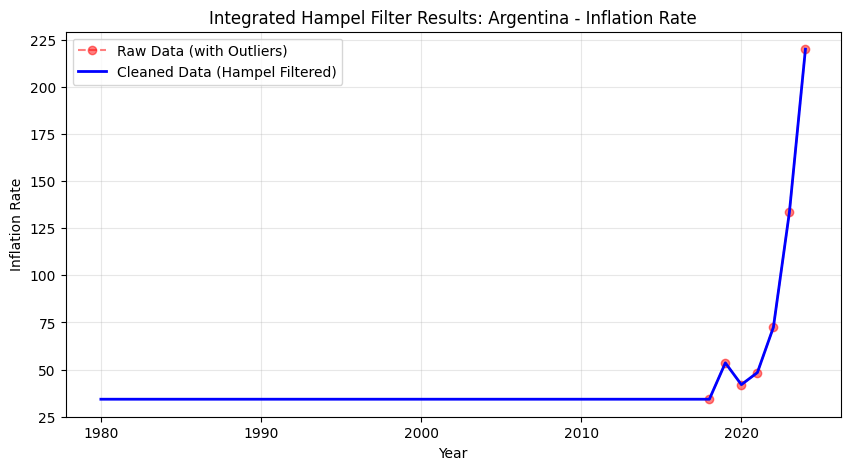

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# For demonstration, we'll show how the filter handled outliers in Argentina's Inflation Rate
country = 'Argentina'
metric = 'Inflation Rate'
df_raw = df_world_bank[df_world_bank['Country'] == country].copy().sort_values('Year')
df_cleaned_demo = df_clean[df_clean['Country'] == country].copy().sort_values('Year')

plt.figure(figsize=(10, 5))
plt.plot(df_raw['Year'], df_raw[metric], color='red', label='Raw Data (with Outliers)', linestyle='--', marker='o', alpha=0.5)
plt.plot(df_cleaned_demo['Year'], df_cleaned_demo[metric], color='blue', label='Cleaned Data (Hampel Filtered)', linewidth=2)
plt.title(f'Integrated Hampel Filter Results: {country} - {metric}')
plt.xlabel('Year')
plt.ylabel(metric)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 15.2 Multicollinearity Network
Visualizing the network of highly correlated features (> 0.85) that we compressed using PCA.

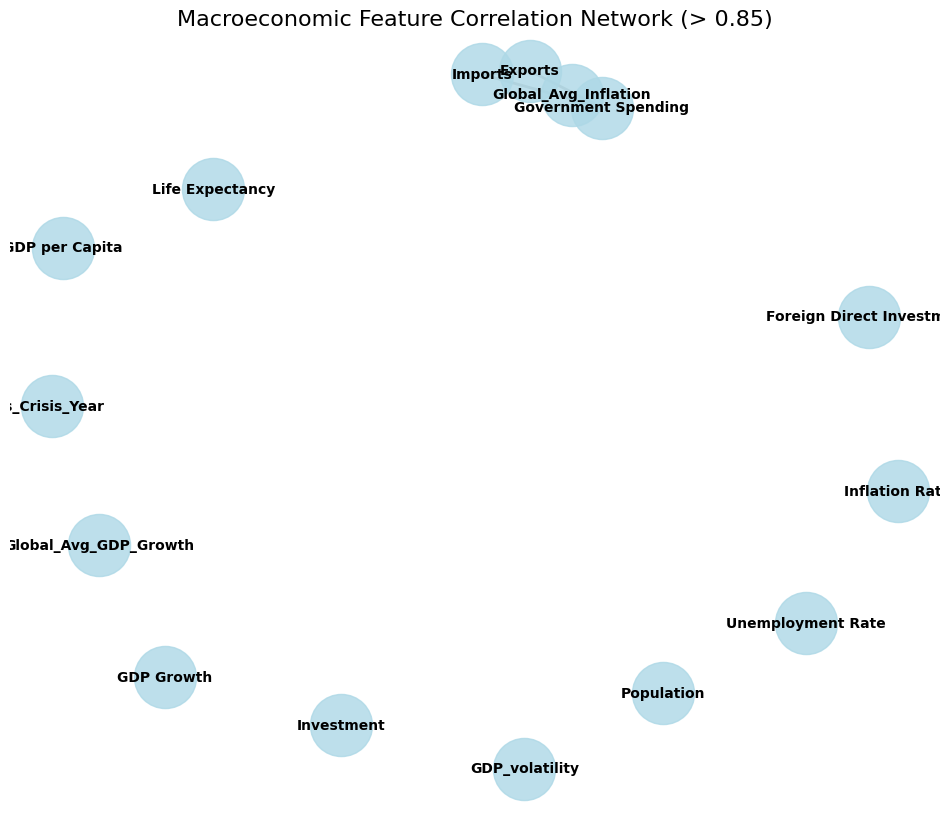

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Macroeconomic Feature Correlation Network (> 0.85)', fontsize=16)
plt.axis('off')
plt.show()


#### 15.3 Feature Importance (RFE Wrapper)
Displaying the predictive power of the final selected features according to the XGBoost wrapper.

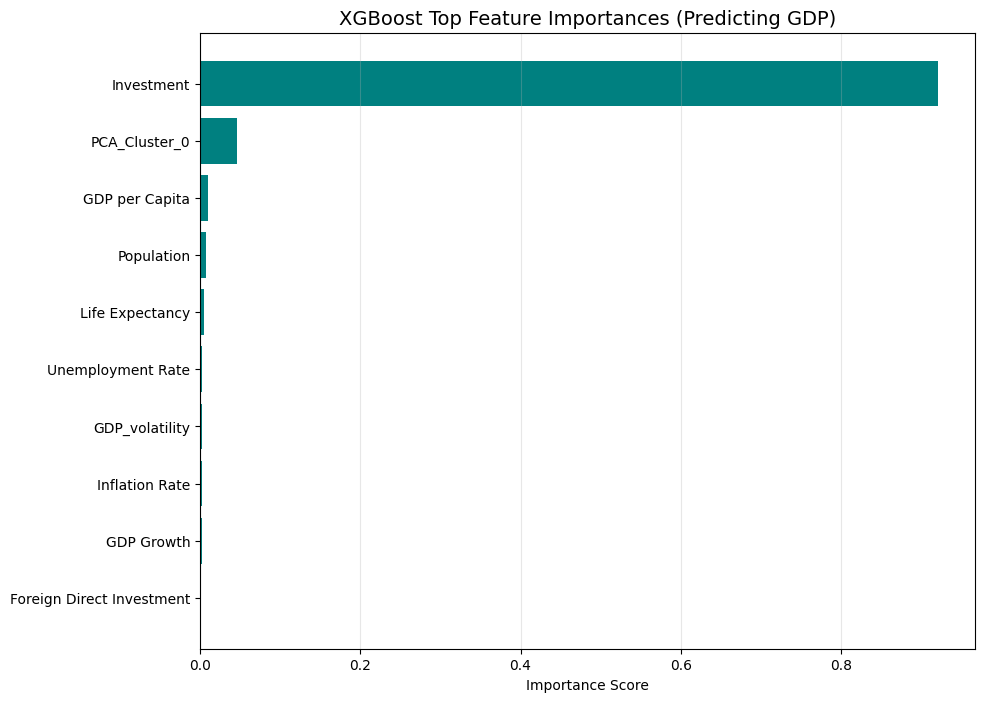

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# rfe.estimator_ holds the model fitted on the *selected* features
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rfe.estimator_.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(importance['Feature'], importance['Importance'], color='teal')
plt.title('XGBoost Top Feature Importances (Predicting GDP)', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()


In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


class Handling:
    def __init__(self):
        self.country_encoder = LabelEncoder()
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()

    def handle_country(self, train_, test_):
        train_ = train_.copy()
        test_ = test_.copy()

        train_["country_id"] = self.country_encoder.fit_transform(train_["Country"])

        # Important: all countries in test must exist in train
        test_["country_id"] = self.country_encoder.transform(test_["Country"])

        train_ = train_.drop(columns=["Country"])
        test_ = test_.drop(columns=["Country"])

        num_countries = len(self.country_encoder.classes_)

        return train_, test_, num_countries

    def scale_features_and_target(self, train_, test_, feature_cols, target_col):
        """
        Fit scalers only on train data to avoid data leakage.
        """

        train_ = train_.copy()
        test_ = test_.copy()

        train_[feature_cols] = self.feature_scaler.fit_transform(train_[feature_cols])
        test_[feature_cols] = self.feature_scaler.transform(test_[feature_cols])

        train_[[target_col]] = self.target_scaler.fit_transform(train_[[target_col]])
        test_[[target_col]] = self.target_scaler.transform(test_[[target_col]])

        return train_, test_

    @staticmethod
    def prepare_multi_output_ds_panel(
        df,
        feature_cols,
        target_col,
        window_size=5,
        batch_size=32,
        shuffle=True
    ):
        """
        Create time-series windows inside each country only.

        X:
            country_in: country id
            ts_in: previous window_size timesteps

        y:
            target value at the next timestep
        """

        X_country = []
        X_ts = []
        y_target = []

        print(f"Preparing panel data with {len(df['country_id'].unique())} countries...")

        for country_id, group in df.groupby("country_id", sort=True):
            group = group.sort_values("Year").reset_index(drop=True)

            n_periods = len(group)

            if n_periods <= window_size:
                print(
                    f"Warning: Country {country_id} has only {n_periods} rows. "
                    f"Needs more than window_size={window_size}. Skipping."
                )
                continue

            ts_data = group[feature_cols].values.astype("float32")
            target_data = group[target_col].values.astype("float32")

            n_windows = n_periods - window_size

            for i in range(n_windows):
                X_country.append(country_id)
                X_ts.append(ts_data[i:i + window_size])
                y_target.append(target_data[i + window_size])

            print(f"Country {country_id}: {n_windows} windows created")

        X_country = np.array(X_country, dtype=np.int32)
        X_ts = np.array(X_ts, dtype=np.float32)

        # Important fix: target must be shape (samples, 1), not (samples,)
        y_target = np.array(y_target, dtype=np.float32).reshape(-1, 1)

        print("\nDataset shapes:")
        print(f"X_country shape: {X_country.shape}")
        print(f"X_ts shape: {X_ts.shape}")
        print(f"y_target shape: {y_target.shape}")

        dataset = tf.data.Dataset.from_tensor_slices(
            (
                {
                    "country_in": X_country,
                    "ts_in": X_ts
                },
                y_target
            )
        )

        if shuffle:
            dataset = dataset.shuffle(buffer_size=min(1000, len(X_country)))

        dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

        return dataset


class Modeling:
    @staticmethod
    def build_lstm_model(
        num_countries,
        num_features,
        window_size=5,
        num_targets=1
    ):
        country_in = layers.Input(
            shape=(),
            name="country_in",
            dtype=tf.int32
        )

        country_emb = layers.Embedding(
            input_dim=num_countries,
            output_dim=8,
            name="country_embedding"
        )(country_in)

        country_emb_seq = layers.RepeatVector(window_size)(country_emb)

        ts_in = layers.Input(
            shape=(window_size, num_features),
            name="ts_in"
        )

        x = layers.Concatenate(name="concat_country_ts")(
            [ts_in, country_emb_seq]
        )

        x = layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.2,
            name="lstm_1"
        )(x)

        x = layers.LSTM(
            32,
            dropout=0.2,
            name="lstm_2"
        )(x)

        x = layers.BatchNormalization(name="batch_norm")(x)

        x = layers.Dense(
            32,
            activation="relu",
            name="dense_1"
        )(x)

        x = layers.Dropout(
            0.2,
            name="dropout_1"
        )(x)

        output = layers.Dense(
            num_targets,
            name="output"
        )(x)

        model = Model(
            inputs={
                "country_in": country_in,
                "ts_in": ts_in
            },
            outputs=output
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss="mse",
            metrics=[
                tf.keras.metrics.MeanAbsoluteError(name="mae"),
                tf.keras.metrics.RootMeanSquaredError(name="rmse")
            ]
        )

        return model


def evaluate_r2_score(model, dataset, target_scaler=None):
    """
    Final global R² evaluation.

    This is the correct final evaluation because it collects all predictions
    first, then calculates R² once on the full test set.
    """

    y_true_all = []
    y_pred_all = []

    for batch_x, batch_y in dataset:
        y_pred = model.predict(batch_x, verbose=0)

        y_true_all.append(batch_y.numpy())
        y_pred_all.append(y_pred)

    y_true_all = np.vstack(y_true_all)
    y_pred_all = np.vstack(y_pred_all)

    # Convert back to original GDP values if target was scaled
    if target_scaler is not None:
        y_true_all = target_scaler.inverse_transform(y_true_all)
        y_pred_all = target_scaler.inverse_transform(y_pred_all)

    r2 = r2_score(y_true_all, y_pred_all)
    mse = mean_squared_error(y_true_all, y_pred_all)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_all, y_pred_all)

    print("\n" + "=" * 70)
    print("FINAL TRUE TEST EVALUATION")
    print("=" * 70)
    print(f"R² Score: {r2:.6f}")
    print(f"MSE: {mse:,.6f}")
    print(f"RMSE: {rmse:,.6f}")
    print(f"MAE: {mae:,.6f}")

    return {
        "r2": r2,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "y_true": y_true_all,
        "y_pred": y_pred_all
    }


def print_true_vs_predicted(results, n=20):
    y_true = results["y_true"]
    y_pred = results["y_pred"]

    print("\n" + "=" * 70)
    print("SAMPLE TRUE VS PREDICTED GDP VALUES")
    print("=" * 70)

    for i in range(min(n, len(y_true))):
        true_val = y_true[i][0]
        pred_val = y_pred[i][0]
        error = true_val - pred_val

        print(
            f"{i + 1:02d}) "
            f"True GDP: {true_val:,.4f} | "
            f"Predicted GDP: {pred_val:,.4f} | "
            f"Error: {error:,.4f}"
        )


if __name__ == "__main__":

    # Required:
    # df_train and df_test must already exist before running this script.
    #
    # Required columns:
    # Country
    # Year
    # GDP
    # plus numerical feature columns

    target_col = "GDP"
    window_size = 5
    batch_size = 32
    epochs = 100

    print("=" * 70)
    print("ORIGINAL GDP VALUES BEFORE SCALING")
    print("=" * 70)

    print(f"df_train GDP min: {df_train[target_col].min()}")
    print(f"df_train GDP max: {df_train[target_col].max()}")
    print(f"df_test GDP min: {df_test[target_col].min()}")
    print(f"df_test GDP max: {df_test[target_col].max()}")

    H = Handling()

    print("\n" + "=" * 70)
    print("ENCODING COUNTRIES")
    print("=" * 70)

    train_, test_, num_countries = H.handle_country(df_train, df_test)

    print(f"Number of countries: {num_countries}")

    train_ = train_.sort_values(["country_id", "Year"]).reset_index(drop=True)
    test_ = test_.sort_values(["country_id", "Year"]).reset_index(drop=True)

    selected_features = [
        col for col in train_.columns
        if col not in [target_col, "country_id", "Year"]
    ]

    print("\nSelected features:")
    for col in selected_features:
        print("-", col)

    print("\n" + "=" * 70)
    print("SCALING FEATURES AND TARGET")
    print("=" * 70)

    train_scaled, test_scaled = H.scale_features_and_target(
        train_,
        test_,
        selected_features,
        target_col
    )

    print(f"Scaled train GDP min: {train_scaled[target_col].min():.6f}")
    print(f"Scaled train GDP max: {train_scaled[target_col].max():.6f}")
    print(f"Scaled test GDP min: {test_scaled[target_col].min():.6f}")
    print(f"Scaled test GDP max: {test_scaled[target_col].max():.6f}")

    print("\n" + "=" * 70)
    print("PREPARING DATASETS")
    print("=" * 70)

    train_ds = H.prepare_multi_output_ds_panel(
        train_scaled,
        selected_features,
        target_col,
        window_size=window_size,
        batch_size=batch_size,
        shuffle=True
    )

    test_ds = H.prepare_multi_output_ds_panel(
        test_scaled,
        selected_features,
        target_col,
        window_size=window_size,
        batch_size=batch_size,
        shuffle=False
    )

    print("\n" + "=" * 70)
    print("VERIFYING ONE TRAINING BATCH")
    print("=" * 70)

    for batch_x, batch_y in train_ds.take(1):
        print("country_in shape:", batch_x["country_in"].shape)
        print("ts_in shape:", batch_x["ts_in"].shape)
        print("target shape:", batch_y.shape)
        print("example scaled target:", batch_y[0].numpy()[0])

    print("\n" + "=" * 70)
    print("BUILDING MODEL")
    print("=" * 70)

    model = Modeling.build_lstm_model(
        num_countries=num_countries,
        num_features=len(selected_features),
        window_size=window_size,
        num_targets=1
    )

    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]

    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=epochs,
        verbose=1,
        callbacks=callbacks
    )

    print("\n" + "=" * 70)
    print("KERAS TEST EVALUATION ON SCALED GDP")
    print("=" * 70)

    test_loss, test_mae, test_rmse = model.evaluate(test_ds, verbose=0)

    print(f"Scaled Test MSE: {test_loss:.6f}")
    print(f"Scaled Test MAE: {test_mae:.6f}")
    print(f"Scaled Test RMSE: {test_rmse:.6f}")

    # Final correct R² evaluation
    results = evaluate_r2_score(
        model=model,
        dataset=test_ds,
        target_scaler=H.target_scaler
    )

    print_true_vs_predicted(results, n=20)

    print("\n" + "=" * 70)
    print("RANGE CHECK")
    print("=" * 70)

    print("Original df_test GDP range:")
    print(f"df_test GDP min: {df_test[target_col].min()}")
    print(f"df_test GDP max: {df_test[target_col].max()}")

    print("\nTrue GDP range after inverse transform:")
    print(f"True GDP min: {results['y_true'].min()}")
    print(f"True GDP max: {results['y_true'].max()}")

    print("\nPredicted GDP range after inverse transform:")
    print(f"Predicted GDP min: {results['y_pred'].min()}")
    print(f"Predicted GDP max: {results['y_pred'].max()}")

    print("\nFinal R² Score:", results["r2"])

ORIGINAL GDP VALUES BEFORE SCALING
df_train GDP min: -1.9373759270398183
df_train GDP max: 2.210898631708082
df_test GDP min: -0.6262159050684042
df_test GDP max: 2.3879336101478685

ENCODING COUNTRIES
Number of countries: 96

Selected features:
- Foreign Direct Investment
- GDP Growth
- GDP per Capita
- Inflation Rate
- Investment
- Life Expectancy
- Population
- Unemployment Rate
- GDP_volatility
- PCA_Cluster_0

SCALING FEATURES AND TARGET
Scaled train GDP min: -2.729805
Scaled train GDP max: 3.093278
Scaled test GDP min: -0.889283
Scaled test GDP max: 3.341788

PREPARING DATASETS
Preparing panel data with 96 countries...
Country 0: 31 windows created
Country 1: 31 windows created
Country 2: 31 windows created
Country 3: 31 windows created
Country 4: 31 windows created
Country 5: 31 windows created
Country 6: 31 windows created
Country 7: 31 windows created
Country 8: 31 windows created
Country 9: 31 windows created
Country 10: 31 windows created
Country 11: 31 windows created
Count

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ country_in          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embedding   │ (None, 8)         │        768 │ country_in[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ts_in (InputLayer)  │ (None, 5, 10)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 5, 8)      │          0 │ country_embeddin… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_country_ts   │ (None, 5, 18)     │          0 │ ts_in[0][0],      │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 5, 64)     │     21,248 │ concat_country_t… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 32)        │        128 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ batch_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,585 (139.00 KB)

 Non-trainable params: 64 (256.00 B)


TRAINING
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.2095 - mae: 0.8498 - rmse: 1.0998 - val_loss: 0.9476 - val_mae: 0.7536 - val_rmse: 0.9734 - learning_rate: 1.0000e-04
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5929 - mae: 0.5941 - rmse: 0.7700 - val_loss: 0.6638 - val_mae: 0.6227 - val_rmse: 0.8147 - learning_rate: 1.0000e-04
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4702 - mae: 0.5256 - rmse: 0.6857 - val_loss: 0.4041 - val_mae: 0.4803 - val_rmse: 0.6357 - learning_rate: 1.0000e-04
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4305 - mae: 0.5091 - rmse: 0.6561 - val_loss: 0.2099 - val_mae: 0.3378 - val_rmse: 0.4581 - learning_rate: 1.0000e-04
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3968 - mae: 0.4901 - rmse: 0.6299 - val_loss: 0.1074 - val_mae: 0.2532 - val_rmse: 0.3277 - learning_rate: 1.0000e-04
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3739 - mae: 0.4739 - rmse: 0.6115 